# Evaluate RakForest CNN

ประเมินโมเดล `models/rakforest_cnn_best.pt` บน `processed/forest_sound_16k_5s/test` โดยใช้ preprocessing เดียวกับ `03_train_cnn.ipynb` ทุกประการ

ผลลัพธ์จะถูกบันทึกที่:
- `reports/confusion_matrix.png`
- `reports/classification_report.csv`

Notebook นี้ไม่เทรนโมเดลใหม่และไม่แก้ไขไฟล์ใน raw/processed dataset

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import torch
import torch.nn as nn
import torchaudio
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset

sns.set_theme(style="whitegrid")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "processed" / "forest_sound_16k_5s").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("ไม่พบ processed/forest_sound_16k_5s")

PROJECT_ROOT = find_project_root()
DATASET_ROOT = PROJECT_ROOT / "processed" / "forest_sound_16k_5s"
TEST_ROOT = DATASET_ROOT / "test"
MODEL_PATH = PROJECT_ROOT / "models" / "rakforest_cnn_best.pt"
REPORTS_DIR = PROJECT_ROOT / "reports"
CONFUSION_MATRIX_PATH = REPORTS_DIR / "confusion_matrix.png"
CLASSIFICATION_REPORT_PATH = REPORTS_DIR / "classification_report.csv"
SAMPLE_RATE = 16_000
CLIP_SECONDS = 5
NUM_SAMPLES = SAMPLE_RATE * CLIP_SECONDS
BATCH_SIZE = 32
AUDIO_EXTENSIONS = {".wav", ".wave", ".flac", ".aiff", ".aif"}

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"ไม่พบโมเดล: {MODEL_PATH}")
print(f"Device: {DEVICE}")
print(f"Model: {MODEL_PATH}")
print(f"Test data: {TEST_ROOT}")

Device: mps
Model: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/models/rakforest_cnn_best.pt
Test data: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/processed/forest_sound_16k_5s/test


## 1. โหลด checkpoint และสร้าง label จากโฟลเดอร์ test

In [10]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
class_names = list(checkpoint["class_names"])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

test_classes = sorted(p.name for p in TEST_ROOT.iterdir() if p.is_dir())
if set(test_classes) != set(class_names):
    raise ValueError(f"คลาสใน test ไม่ตรงกับ checkpoint: {test_classes} vs {class_names}")
print("Classes:", class_names)
print("Checkpoint best validation accuracy:", checkpoint.get("best_val_accuracy", "ไม่ระบุ"))

Classes: ['fire', 'logging', 'natural sound', 'poaching']
Checkpoint best validation accuracy: 0.8732876712328768


In [11]:
class AudioFolderTestDataset(Dataset):
    # Same waveform loading, mono conversion, padding and truncation as 03_train_cnn.ipynb.
    def __init__(self, root, class_to_idx, sample_rate=SAMPLE_RATE, num_samples=NUM_SAMPLES):
        self.root = Path(root)
        self.class_to_idx = class_to_idx
        self.sample_rate = sample_rate
        self.num_samples = num_samples
        self.items = []
        for class_name, label in class_to_idx.items():
            for path in sorted((self.root / class_name).rglob("*")):
                if path.is_file() and path.suffix.lower() in AUDIO_EXTENSIONS:
                    self.items.append((path, label))
        if not self.items:
            raise ValueError(f"ไม่พบไฟล์เสียงใน {self.root}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, index):
        path, label = self.items[index]
        waveform, sr = sf.read(path, dtype="float32", always_2d=True)
        if sr != self.sample_rate:
            raise ValueError(f"{path} มี sample rate {sr}, คาดหวัง {self.sample_rate}")
        waveform = torch.from_numpy(waveform.mean(axis=1))
        if waveform.numel() < self.num_samples:
            waveform = torch.nn.functional.pad(waveform, (0, self.num_samples - waveform.numel()))
        else:
            waveform = waveform[:self.num_samples]
        return waveform, torch.tensor(label, dtype=torch.long), str(path)

test_dataset = AudioFolderTestDataset(TEST_ROOT, class_to_idx)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_counts = pd.Series([label for _, label in test_dataset.items]).map(lambda x: class_names[x]).value_counts().reindex(class_names, fill_value=0)
display(test_counts.rename("files").to_frame())
print(f"Test files: {len(test_dataset):,}")

,files
fire,220
logging,69
natural sound,205
poaching,91


Test files: 585


## 2. Preprocessing Mel-Spectrogram ให้เหมือนตอนเทรน

In [12]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,
    hop_length=256,
    n_mels=64,
    f_min=20,
    f_max=SAMPLE_RATE // 2,
).to(DEVICE)

def to_log_mel(waveforms):
    # Must match 03_train_cnn.ipynb: log power, per-sample normalization, channel dim.
    mel = mel_transform(waveforms.to(DEVICE))
    mel = torch.log(mel.clamp_min(1e-6))
    mel = (mel - mel.mean(dim=(-2, -1), keepdim=True)) / (mel.std(dim=(-2, -1), keepdim=True) + 1e-6)
    return mel.unsqueeze(1)

class SmallAudioCNN(nn.Module):
    # Architecture must match 03_train_cnn.ipynb exactly.
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.30), nn.Linear(64, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallAudioCNN(len(class_names)).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
criterion = nn.CrossEntropyLoss()
print("Loaded checkpoint; no training will be performed.")
print(f"Mel shape example: {tuple(to_log_mel(torch.zeros(1, NUM_SAMPLES)).shape)}")

Loaded checkpoint; no training will be performed.
Mel shape example: (1, 1, 64, 313)


## 3. Test loss และ test accuracy

In [13]:
all_labels, all_predictions, all_probabilities, all_paths = [], [], [], []
total_loss = 0.0
total_items = 0

with torch.no_grad():
    for waveforms, labels, paths in test_loader:
        labels = labels.to(DEVICE)
        logits = model(to_log_mel(waveforms))
        loss = criterion(logits, labels)
        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_items += labels.size(0)
        all_labels.extend(labels.cpu().numpy().tolist())
        all_predictions.extend(predictions.cpu().numpy().tolist())
        all_probabilities.extend(probabilities.cpu().numpy().tolist())
        all_paths.extend(paths)

test_loss = total_loss / total_items
test_accuracy = float(np.mean(np.asarray(all_labels) == np.asarray(all_predictions)))
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f} ({test_accuracy:.2%})")

Test loss: 0.3524
Test accuracy: 0.8769 (87.69%)


## 4. Classification report

In [14]:
report_dict = classification_report(
    all_labels, all_predictions, labels=list(range(len(class_names))),
    target_names=class_names, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).T
report_df.index.name = "class"
report_df = report_df.reset_index()
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
report_df.to_csv(CLASSIFICATION_REPORT_PATH, index=False)
display(report_df.round(4))
print(f"บันทึก classification report: {CLASSIFICATION_REPORT_PATH}")

,class,precision,recall,f1-score,support
0,fire,0.9730,0.9818,0.9774,220.0000
1,logging,0.5833,0.8116,0.6788,69.0000
2,natural sound,0.8830,0.8098,0.8448,205.0000
3,poaching,0.9494,0.8242,0.8824,91.0000
4,accuracy,0.8769,0.8769,0.8769,0.8769
5,macro avg,0.8472,0.8568,0.8458,585.0000
6,weighted avg,0.8918,0.8769,0.8809,585.0000


บันทึก classification report: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/reports/classification_report.csv


## 5. Confusion matrix

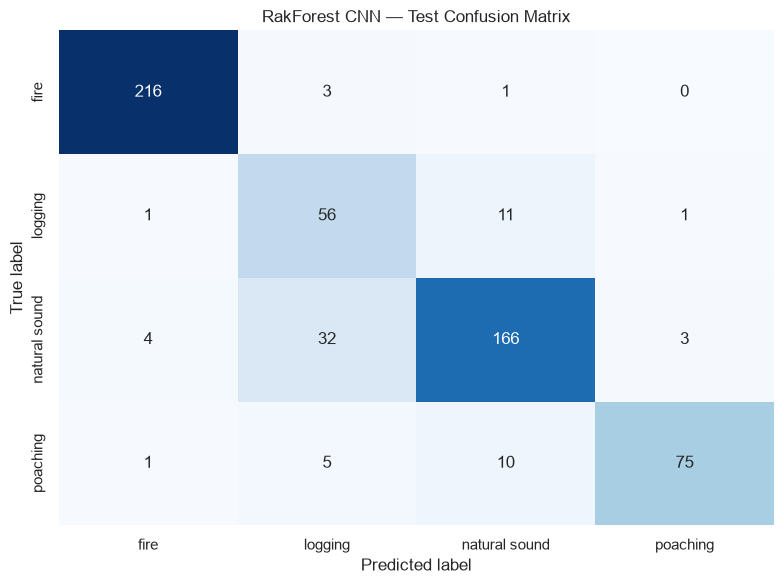

บันทึก confusion matrix: /Users/guidegiegg/งาน/โปรเจคเล็กๆ/PrePair_Sound/reports/confusion_matrix.png


In [15]:
cm = confusion_matrix(all_labels, all_predictions, labels=list(range(len(class_names))))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title("RakForest CNN — Test Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=180, bbox_inches="tight")
plt.show()
print(f"บันทึก confusion matrix: {CONFUSION_MATRIX_PATH}")

## 6. ตัวอย่างไฟล์ที่ทำนายผิด 8 ตัวอย่าง

,file,true_label,predicted_label,confidence
0,logging/11_11152__seg00.wav,logging,fire,100.00%
1,natural sound/9_10959__seg00.wav,natural sound,fire,98.08%
2,natural sound/20_12027__seg00.wav,natural sound,logging,94.31%
3,poaching/15_11505__seg00.wav,poaching,natural sound,92.94%
4,logging/11_11156__seg00.wav,logging,natural sound,92.48%
5,natural sound/19_11923__seg00.wav,natural sound,logging,91.92%
6,natural sound/4_10437__seg00.wav,natural sound,logging,90.97%
7,natural sound/4_10433__seg00.wav,natural sound,logging,90.77%


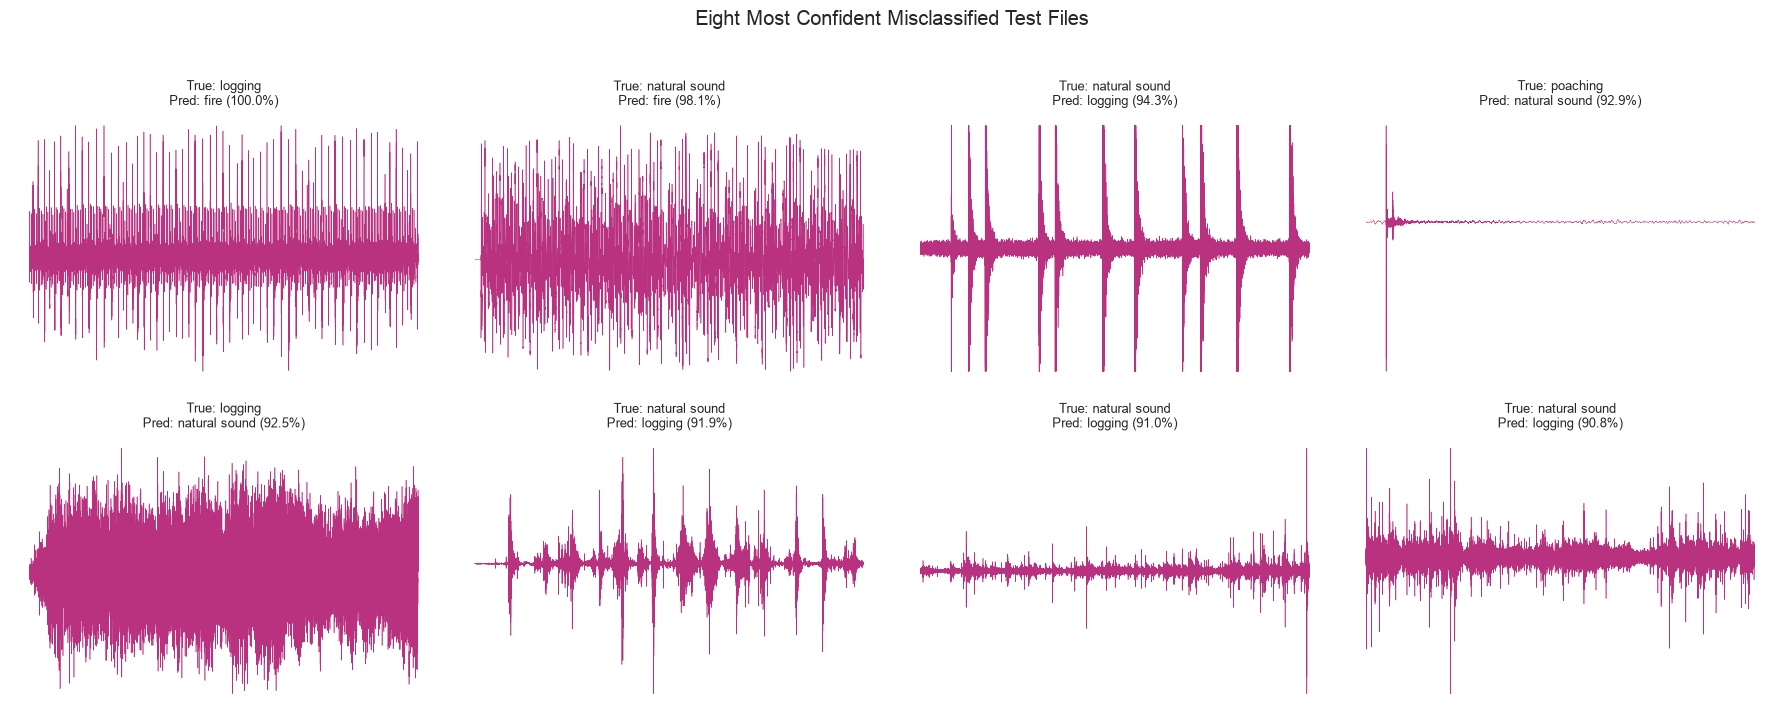

In [16]:
mistakes = []
for path, true_idx, pred_idx, probs in zip(all_paths, all_labels, all_predictions, all_probabilities):
    if true_idx != pred_idx:
        mistakes.append({
            "file": str(Path(path).relative_to(TEST_ROOT)),
            "true_label": class_names[true_idx],
            "predicted_label": class_names[pred_idx],
            "confidence": float(max(probs)),
        })

mistakes_df = pd.DataFrame(mistakes).sort_values("confidence", ascending=False).head(8).reset_index(drop=True)
display(mistakes_df.style.format({"confidence": "{:.2%}"}))

if not mistakes_df.empty:
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    axes = np.asarray(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for ax, row in zip(axes, mistakes_df.to_dict("records")):
        path = TEST_ROOT / row["file"]
        waveform, sr = sf.read(path, dtype="float32", always_2d=True)
        waveform = waveform.mean(axis=1)
        time = np.arange(len(waveform)) / sr
        ax.plot(time, waveform, linewidth=0.4, color="#b83280")
        ax.set_title(f"True: {row['true_label']}\nPred: {row['predicted_label']} ({row['confidence']:.1%})", fontsize=9)
        ax.set_xlabel("sec")
        ax.set_ylabel("amp")
    fig.suptitle("Eight Most Confident Misclassified Test Files", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("ไม่พบไฟล์ที่ทำนายผิด")

## สรุปไฟล์ผลลัพธ์

- Classification report: `reports/classification_report.csv`
- Confusion matrix: `reports/confusion_matrix.png`
- ไม่มีการเทรนโมเดลใหม่ และไม่มีการแก้ไข dataset